# Knowledge Graph Construction — Azure OpenAI Edition

**Original:** [Anthropic claude-cookbooks](https://github.com/anthropics/claude-cookbooks/blob/main/capabilities/knowledge_graph/guide.ipynb)

---

## Core Idea

There are two ways to build a knowledge graph depending on your data:

| Data type | How the graph is built |
|---|---|
| **Unstructured** (Wikipedia articles, fault tickets, reports) | **LLM reads the text** and extracts entities + relations → graph |
| **Structured** (Matrix,  XML, database rows) | **Parser reads** rows/columns deterministically → graph |

This notebook demonstrates the **unstructured → LLM → graph** path.
The querying and summarisation cells work identically regardless of how the graph was built.

## Pipeline Overview

```
Raw text documents
      ↓  [Cell 3]  LLM extraction, 1 API call per document
Raw entities + relations (with surface-form duplicates)
      ↓  [Cell 4]  LLM resolution, 1 API call per entity type
Canonical lookup tables (alias_to_canonical, canonical_info)
      ↓  [Cell 5]  Graph assembly, pure Python, no API calls
NetworkX graph (typed nodes, directed edges, provenance)
      ↓  [Cell 6]  LLM summarisation, 1 API call per hub node
Enriched graph (profiles on high-degree nodes)
      ↓  [Cell 7]  Multi-hop querying grounded vs ungrounded comparison
Answers with edge-level citations
```


## 0. Setup

In [11]:
%%capture
# Install required packages (%%capture suppresses pip output)
%pip install openai networkx matplotlib python-dotenv pydantic httpx


In [ ]:
import json
import os
from collections import defaultdict
from typing import Literal
from urllib.parse import quote

import httpx
import networkx as nx
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
from openai import AzureOpenAI, DefaultHttpxClient
from pydantic import BaseModel

load_dotenv()


EXTRACTION_DEPLOYMENT = os.getenv("AZURE_DEPLOYMENT_EXTRACTION")
SYNTHESIS_DEPLOYMENT  = os.getenv("AZURE_DEPLOYMENT_SYNTHESIS")

load_dotenv()
proxy = os.environ.get("HTTPS_PROXY")

client = AzureOpenAI(
    azure_endpoint=os.environ.get("AZURE_OPENAI_ENDPOINT"),
    api_key=os.environ.get("AZURE_OPENAI_API_KEY"),
    api_version=os.environ.get("AZURE_OPENAI_API_VERSION"),
    azure_deployment="gpt-4.1"
    
)
EXTRACTION_DEPLOYMENT = "gpt-4.1"
SYNTHESIS_DEPLOYMENT  = "gpt-4.1"

print(f"Extraction deployment : {EXTRACTION_DEPLOYMENT}")
print(f"Synthesis  deployment : {SYNTHESIS_DEPLOYMENT}")

Extraction deployment : gpt-4.1
Synthesis  deployment : gpt-4.1


## 1. Corpus

Six Apollo programme articles stored as local Python strings — no network required.

These articles deliberately share overlapping entities with different surface forms:
- `"Neil Armstrong"` / `"Neil Alden Armstrong"` / `"Armstrong"` - same person
- `"Buzz Aldrin"` / `"Edwin Aldrin"` - same person (Edwin is his birth name)
- `"Kennedy Space Center"` / `"KSC"` - same location

This makes them a good stress test for entity resolution.


In [13]:
# Each document: id (int), title (used as source_doc label), text (prose the LLM reads)
documents = [
    {
        'id': 0, 'title': 'Apollo program',
        'text': (
            'The Apollo program, also known as Project Apollo, was the United States human spaceflight '
            'program led by NASA, which landed the first humans on the Moon in 1969. Apollo was conceived '
            'in 1960 during the Eisenhower presidency and executed after Project Gemini. President John F. '
            'Kennedy committed the nation to a crewed lunar landing before the end of the 1960s. The '
            'program used the Saturn V rocket, developed by NASA Marshall Space Flight Center. Twelve '
            'astronauts walked on the Moon across six successful landing missions between 1969 and 1972.'
        ),
    },
    {
        'id': 1, 'title': 'Apollo 11',
        'text': (
            'Apollo 11 was the American spaceflight that first landed humans on the Moon. Commander Neil '
            'Armstrong and Lunar Module Pilot Buzz Aldrin landed on July 20 1969 while Command Module '
            'Pilot Michael Collins orbited above. Armstrong became the first person to step onto the lunar '
            'surface followed by Aldrin 19 minutes later. The mission launched atop a Saturn V rocket '
            'from Launch Complex 39A at Kennedy Space Center. Apollo 11 fulfilled President Kennedy goal '
            'of reaching the Moon before the end of the 1960s.'
        ),
    },
    {
        'id': 2, 'title': 'Neil Armstrong',
        'text': (
            'Neil Alden Armstrong was an American astronaut and aeronautical engineer who became the first '
            'person to walk on the Moon on July 21 1969. He served as mission commander of Apollo 11. '
            'Before joining NASA Armstrong was a naval aviator who flew 78 combat missions during the '
            'Korean War. He commanded Gemini 8 in 1966 performing the first successful docking of two '
            'spacecraft. Armstrong earned a degree from Purdue University and died on August 25 2012.'
        ),
    },
    {
        'id': 3, 'title': 'Saturn V',
        'text': (
            'Saturn V was an American super heavy-lift launch vehicle developed by NASA under the Apollo '
            'program for human exploration of the Moon. Designed by Wernher von Braun at the Marshall '
            'Space Flight Center it stands 110.6 metres tall and remains the most powerful rocket ever '
            'brought to operational status. Saturn V launched all Apollo lunar missions from Kennedy Space '
            'Center. 13 Saturn V rockets were launched between 1967 and 1973 with no payload loss.'
        ),
    },
    {
        'id': 4, 'title': 'Buzz Aldrin',
        'text': (
            'Buzz Aldrin born Edwin Eugene Aldrin Jr is an American former astronaut and fighter pilot. '
            'He was the Lunar Module Pilot on Apollo 11 becoming the second person to walk on the Moon '
            'on July 21 1969. Aldrin flew 66 combat missions during the Korean War and holds a Doctor of '
            'Science in Astronautics from MIT. He flew on Gemini 12 in 1966. Aldrin legally changed his '
            'first name from Edwin to Buzz in 1988.'
        ),
    },
    {
        'id': 5, 'title': 'Kennedy Space Center',
        'text': (
            'Kennedy Space Center KSC is one of NASA primary launch centers located on Merritt Island '
            'Florida. It has been the launch site for every US human spaceflight since 1968. KSC was '
            'established in 1962 and named after President John F. Kennedy. The center includes Launch '
            'Complex 39 from which all Apollo lunar missions launched. Saturn V rockets were processed '
            'in the Vehicle Assembly Building one of the largest buildings by volume in the world.'
        ),
    },
]

print(f'Loaded {len(documents)} documents (local)')
print(f"Sample: {documents[0]['title']}")
print(documents[0]['text'][:200] + '...')


Loaded 6 documents (local)
Sample: Apollo program
The Apollo program, also known as Project Apollo, was the United States human spaceflight program led by NASA, which landed the first humans on the Moon in 1969. Apollo was conceived in 1960 during th...


## 2. Pydantic Schemas : the LLM output contract

Passing a Pydantic model as `response_format=` to `beta.chat.completions.parse()`
constrains token generation so the response **always validates** against the schema.
No regex. No `json.loads`. No defensive `isinstance` checks. If the call returns, the object is valid.

Three schemas cover the three pipeline stages:

| Schema | Stage | Purpose |
|---|---|---|
| `ExtractedGraph` | Extraction | Entities + relations found in one document |
| `ResolvedClusters` | Resolution | Clusters of surface-form variants |
| `EntityProfile` | Summarisation | Rich profile for a hub node |

**Adapting `EntityProfile` to your domain:**
```python
#  fault tickets
class EntityProfile(BaseModel):
    summary: str
    affected_ecus: list[str]
    fault_pattern: Literal['timeout', 'value_out_of_range', 'missing', 'other']
    severity: Literal['critical', 'major', 'minor']

# Any causal graph
class EntityProfile(BaseModel):
    summary: str
    root_cause_candidates: list[str]
    causal_position: Literal['upstream', 'downstream', 'isolated']
    sw_regression_risk: bool
    prevalence: float
```
`Entity` and `Relation` are generic and reusable unchanged across domains.


In [14]:
# ── Extraction schemas ───────────────────────────────────────────────────────

# Literal constrains the LLM to exactly these 5 strings — no hallucinated types
EntityType = Literal['PERSON', 'ORGANIZATION', 'LOCATION', 'EVENT', 'ARTIFACT']
ENTITY_TYPES = ['PERSON', 'ORGANIZATION', 'LOCATION', 'EVENT', 'ARTIFACT']


class Entity(BaseModel):
    name: str          # surface form as it appears in the text
    type: EntityType   # one of the 5 constrained types
    description: str   # one sentence grounded in this document — ammunition for resolution


class Relation(BaseModel):
    source: str      # name of source entity — must be in the entities list
    predicate: str   # short verb phrase: 'commanded', 'launched from', 'part of'
    target: str      # name of target entity — must be in the entities list


class ExtractedGraph(BaseModel):
    """Top-level output of the extraction LLM call. One instance per document."""
    entities: list[Entity]
    relations: list[Relation]


# ── Resolution schemas ────────────────────────────────────────────────────────

class Cluster(BaseModel):
    canonical: str       # chosen authoritative name: 'Buzz Aldrin'
    aliases: list[str]   # ALL surface forms incl. canonical: ['Buzz Aldrin', 'Edwin Aldrin']


class ResolvedClusters(BaseModel):
    """Wrapper needed because response_format requires a top-level object, not a bare list."""
    clusters: list[Cluster]


# ── Summarisation schemas — redesign this per domain ─────────────────────────

class TimeRange(BaseModel):
    start: str   # 'YYYY', 'YYYY-MM', or 'unknown'
    end: str     # 'YYYY', 'YYYY-MM', or 'ongoing'


class EntityProfile(BaseModel):
    summary: str             # 2-3 paragraph synthesis
    key_facts: list[str]     # 3-5 atomic facts traceable to a source document
    time_range: TimeRange    # nested object — demonstrates structured nesting in schemas


print('Schemas defined.')
print('ExtractedGraph  → used in extract()')
print('ResolvedClusters → used in resolve()')
print('EntityProfile    → used in summarize_entity()')


Schemas defined.
ExtractedGraph  → used in extract()
ResolvedClusters → used in resolve()
EntityProfile    → used in summarize_entity()


## 3. Entity and Relation Extraction

One LLM call per document turns prose into a typed graph fragment.

**Why LLM instead of classical NLP?**
Classical NLP + relation extraction requires domain-labeled training data.
The LLM collapses entity recognition, relation classification, coreference, and description
generation into a single prompt no training data, no domain-specific model.

**Why keep raw duplicates?**
`"Neil Armstrong"` will appear from 2-3 documents. This is intentional.
The per-document descriptions are evidence for the resolver in the next step.
Deduplicating here would discard that evidence.


In [15]:
# The prompt encodes three extraction rules:
#   1. Selective: only entities central to THIS document, not incidental mentions
#   2. Described: one sentence per entity grounded in this document
#      (these descriptions are the disambiguation evidence for entity resolution)
#   3. Closed: every relation must connect two extracted entities — no dangling edges
EXTRACTION_PROMPT = """Extract a knowledge graph from the document below.

<document>
{text}
</document>

Guidelines:
- Extract only entities that are central to what this document is about.
- For each entity write a one-sentence description grounded in this document.
  These descriptions disambiguate entities with similar names in a later step.
- Predicates should be short verb phrases: commanded, launched from, part of.
- Every relation must connect two entities you extracted."""


def extract(text: str) -> ExtractedGraph:
    """One LLM call on one document. Returns a validated ExtractedGraph object."""
    response = client.beta.chat.completions.parse(
        model=EXTRACTION_DEPLOYMENT,   # cheaper model — task is mechanical pattern matching
        max_tokens=2048,
        messages=[{'role': 'user', 'content': EXTRACTION_PROMPT.format(text=text)}],
        response_format=ExtractedGraph,   # guarantees schema-valid response
    )
    # .parsed returns the Pydantic object directly — no json.loads(), no KeyError risk
    return response.choices[0].message.parsed


In [16]:
# ── Extraction loop ───────────────────────────────────────────────────────────
# Flatten all LLM outputs into two plain lists.
# source_doc is injected here (not in the schema) for provenance tracking later.
raw_entities  = []
raw_relations = []

for doc in documents:
    try:
        result = extract(doc['text'])
    except Exception as e:
        print(f"Skipping {doc['title']}: {e}")
        continue   # one failed doc skips, not the whole loop

    for ent in result.entities:
        # model_dump() converts Pydantic -> plain dict; ** unpacks it
        # source_doc is appended alongside to record which document produced this entity
        raw_entities.append({**ent.model_dump(), 'source_doc': doc['title']})

    for rel in result.relations:
        raw_relations.append({**rel.model_dump(), 'source_doc': doc['title']})

    print(f"{doc['title']:<25} {len(result.entities):>3} entities  {len(result.relations):>3} relations")

print(f'\nTotal: {len(raw_entities)} raw entities, {len(raw_relations)} raw relations')
print('Duplicates are intentional — same entity extracted from multiple documents.')


Apollo program              8 entities    7 relations
Apollo 11                   9 entities   10 relations
Neil Armstrong              7 entities    6 relations
Saturn V                    6 entities    6 relations
Buzz Aldrin                 6 entities    6 relations
Kennedy Space Center        8 entities    8 relations

Total: 44 raw entities, 43 raw relations
Duplicates are intentional — same entity extracted from multiple documents.


In [17]:
# ── Inspect surface-form variants ────────────────────────────────────────────
# Zero LLM calls. Pure Python inspection.
# Goal: see the entity resolution problem before spending synthesis model tokens on it.
# If you spot wrong extractions or incidental mentions, fix the extraction prompt above
# and re-run  cheaper than fixing it in the resolver.

by_type = defaultdict(list)   # auto-creates [] on first access
for e in raw_entities:
    by_type[e['type']].append(e['name'])   # includes duplicates

for etype, names in sorted(by_type.items()):
    # len(names)      = total mentions across all docs (includes cross-doc duplicates)
    # len(set(names)) = unique surface forms
    print(f"{etype} ({len(names)} mentions, {len(set(names))} unique surface forms):")
    for name in sorted(set(names)):
        print(f'  {name}')
    print()

# Expected pairs to spot:
#   Neil Armstrong / Neil Alden Armstrong / Armstrong    -> same person
#   Buzz Aldrin / Edwin Aldrin                           -> same person (birth name)
#   Kennedy Space Center / KSC                          -> same location


ARTIFACT (6 mentions, 4 unique surface forms):
  Launch Complex 39
  Saturn V
  Saturn V rocket
  Vehicle Assembly Building

EVENT (13 mentions, 9 unique surface forms):
  Apollo 11
  Apollo lunar missions
  Apollo program
  Eisenhower presidency
  Gemini 12
  Gemini 8
  Korean War
  Moon landing on July 21, 1969
  Project Gemini

LOCATION (9 mentions, 5 unique surface forms):
  Kennedy Space Center
  Launch Complex 39A
  Marshall Space Flight Center
  Merritt Island, Florida
  Moon

ORGANIZATION (7 mentions, 4 unique surface forms):
  MIT
  NASA
  NASA Marshall Space Flight Center
  Purdue University

PERSON (9 mentions, 8 unique surface forms):
  Buzz Aldrin
  John F. Kennedy
  Michael Collins
  Neil Alden Armstrong
  Neil Armstrong
  President John F. Kennedy
  President Kennedy
  Wernher von Braun



## 4. Entity Resolution

**The problem:** The same real-world entity appears under multiple surface forms.
Building a graph from raw names produces a fractured mess - disconnected duplicate nodes.

**Why string similarity fails:**
Edit distance catches typos. `"Edwin Aldrin"` vs `"Buzz Aldrin"` - zero character overlap.
The LLM reads the descriptions and reasons: *same mission, same role, same person*.

**Approach:** One LLM call per entity type. Send unique (name, description) pairs.
The LLM clusters them and returns canonical names with all aliases.

**Output - two lookup tables:**
```python
alias_to_canonical = {
    'Neil Armstrong':       'Neil Alden Armstrong',
    'Neil Alden Armstrong': 'Neil Alden Armstrong',  # canonical maps to itself
    'Armstrong':            'Neil Alden Armstrong',
    'Edwin Aldrin':         'Buzz Aldrin',
    'KSC':                  'Kennedy Space Center',
}

canonical_info = {
    'Neil Alden Armstrong': {'type': 'PERSON', 'aliases': ['Neil Armstrong', ...]},
    'Buzz Aldrin':          {'type': 'PERSON', 'aliases': ['Buzz Aldrin', 'Edwin Aldrin']},
}
```
These two dicts are used in every subsequent step.


In [18]:
# Key instruction: 'Use the descriptions to avoid merging entities that merely share a name.'
# Without this, 'Armstrong' (astronaut) could merge with 'Armstrong' (anything else).
RESOLVE_PROMPT = """Below are {entity_type} entities extracted from several documents.
Some are different surface forms of the same real-world entity.

<entities>
{entity_list}
</entities>

Cluster them. Each input name must appear in exactly one cluster aliases list.
Entities that are genuinely distinct get their own single-element cluster.
Use the descriptions to avoid merging entities that merely share a name.
The canonical name should be the most complete unambiguous form."""


def resolve(entity_type: str, entities: list[dict]) -> list[Cluster]:
    """Cluster surface-form variants for one entity type. Returns list of Cluster."""
    # Deduplicate by name, keeping the first description seen.
    # setdefault: if key exists do nothing; if not, set it.
    # If 'Neil Armstrong' appeared 3 times, we send one entry.
    unique: dict[str, str] = {}
    for e in entities:
        unique.setdefault(e['name'], e['description'])

    entity_list = '\n'.join(f'- {name}: {desc}' for name, desc in unique.items())

    response = client.beta.chat.completions.parse(
        model=SYNTHESIS_DEPLOYMENT,   # stronger model — task requires semantic judgment
        max_tokens=2048,
        messages=[{'role': 'user', 'content': RESOLVE_PROMPT.format(
            entity_type=entity_type, entity_list=entity_list
        )}],
        response_format=ResolvedClusters,
    )
    return response.choices[0].message.parsed.clusters


In [19]:
alias_to_canonical: dict[str, str] = {}
canonical_info:     dict[str, dict] = {}

for etype in ENTITY_TYPES:
    entities_of_type = [e for e in raw_entities if e['type'] == etype]
    if not entities_of_type:
        continue

    try:
        clusters = resolve(etype, entities_of_type)
    except Exception as e:
        # Fallback: one cluster per name — graph stays fragmented but nothing is lost
        print(f'Resolve failed for {etype}: {e}; treating each name as its own cluster')
        clusters = [Cluster(canonical=n, aliases=[n]) for n in {x['name'] for x in entities_of_type}]

    for cluster in clusters:
        canonical_info[cluster.canonical] = {'type': etype, 'aliases': cluster.aliases}
        for alias in cluster.aliases:
            alias_to_canonical[alias] = cluster.canonical   # canonical maps to itself too

# ── Summary ───────────────────────────────────────────────────────────────────
before = len({e['name'] for e in raw_entities})  # unique surface forms
after  = len(canonical_info)                       # canonical nodes after merging
print(f'Entity resolution: {before} unique surface forms -> {after} canonical entities\n')

for canonical, info in sorted(canonical_info.items()):
    aliases   = [a for a in info['aliases'] if a != canonical]
    alias_str = f"  (also: {', '.join(aliases)})" if aliases else ''
    print(f"{info['type']:<14} {canonical}{alias_str}")
    # Over-merge risk:  'Gemini 12' folded into 'Project Gemini' — loses precision
    # Under-merge risk: 'KSC' still separate from 'Kennedy Space Center' — loses connectivity


Entity resolution: 30 unique surface forms -> 26 canonical entities

EVENT          Apollo 11
EVENT          Apollo lunar missions
EVENT          Apollo program
PERSON         Buzz Aldrin
EVENT          Eisenhower presidency
EVENT          Gemini 12
EVENT          Gemini 8
PERSON         John F. Kennedy  (also: President Kennedy, President John F. Kennedy)
LOCATION       Kennedy Space Center
EVENT          Korean War
ARTIFACT       Launch Complex 39
LOCATION       Launch Complex 39A
LOCATION       Marshall Space Flight Center
ORGANIZATION   Massachusetts Institute of Technology  (also: MIT)
LOCATION       Merritt Island, Florida
PERSON         Michael Collins
LOCATION       Moon
EVENT          Moon landing on July 21, 1969
ORGANIZATION   NASA
ORGANIZATION   NASA Marshall Space Flight Center
PERSON         Neil Alden Armstrong  (also: Neil Armstrong)
EVENT          Project Gemini
ORGANIZATION   Purdue University
ARTIFACT       Saturn V rocket  (also: Saturn V)
ARTIFACT       Vehicle Ass

## 5. Graph Assembly

**Zero LLM calls.** Pure deterministic Python.

All raw names are rewritten through `alias_to_canonical` before entering the graph.
A raw relation `source="Edwin Aldrin"` becomes an edge from `"Buzz Aldrin"`.

**Why `MultiDiGraph`?**
- Directed: edge direction carries meaning (`SENDS` vs `RECEIVES` are different)
- Multi: two nodes can share more than one edge (a SWC can both send and receive the same signal)


In [20]:
G = nx.MultiDiGraph()   # directed + allows multiple edges between same pair of nodes

# ── Add nodes ─────────────────────────────────────────────────────────────────
for e in raw_entities:
    canonical = alias_to_canonical.get(e['name'])
    if canonical is None:
        continue   # name was dropped by resolver — silent loss; production code should log this

    if canonical not in G:
        G.add_node(
            canonical,
            type=canonical_info[canonical]['type'],
            description=e['description'],
            source_docs=[],   # will accumulate all docs that mention this entity
            mentions=0,       # total mention count — used to find hub nodes later
        )
    G.nodes[canonical]['source_docs'].append(e['source_doc'])
    G.nodes[canonical]['mentions'] += 1

# ── Add edges ─────────────────────────────────────────────────────────────────
for r in raw_relations:
    src = alias_to_canonical.get(r['source'])
    tgt = alias_to_canonical.get(r['target'])
    # src != tgt guards against self-loops introduced by over-merging
    if src and tgt and src != tgt:
        G.add_edge(src, tgt, predicate=r['predicate'], source_doc=r['source_doc'])

# ── Clean up source_docs ──────────────────────────────────────────────────────
# Same doc can appear multiple times if entity was mentioned repeatedly within it
for n in G.nodes:
    G.nodes[n]['source_docs'] = sorted(set(G.nodes[n]['source_docs']))

# ── Stats ─────────────────────────────────────────────────────────────────────
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
# weakly_connected_components: count of disconnected islands.
# 1 = fully connected. >1 = some entities were never linked to the main cluster.
print(f'Connected components: {nx.number_weakly_connected_components(G)}')
print('\nTop hub nodes (highest degree = most connections):')
for node, deg in sorted(G.degree(), key=lambda x: -x[1])[:5]:
    print(f"  {node:<35} degree {deg:>2}  ({G.nodes[node]['type']})")


Graph: 26 nodes, 43 edges
Connected components: 1

Top hub nodes (highest degree = most connections):
  Saturn V rocket                     degree 10  (ARTIFACT)
  Apollo 11                           degree 10  (EVENT)
  Apollo program                      degree  8  (EVENT)
  Neil Alden Armstrong                degree  8  (PERSON)
  Buzz Aldrin                         degree  7  (PERSON)


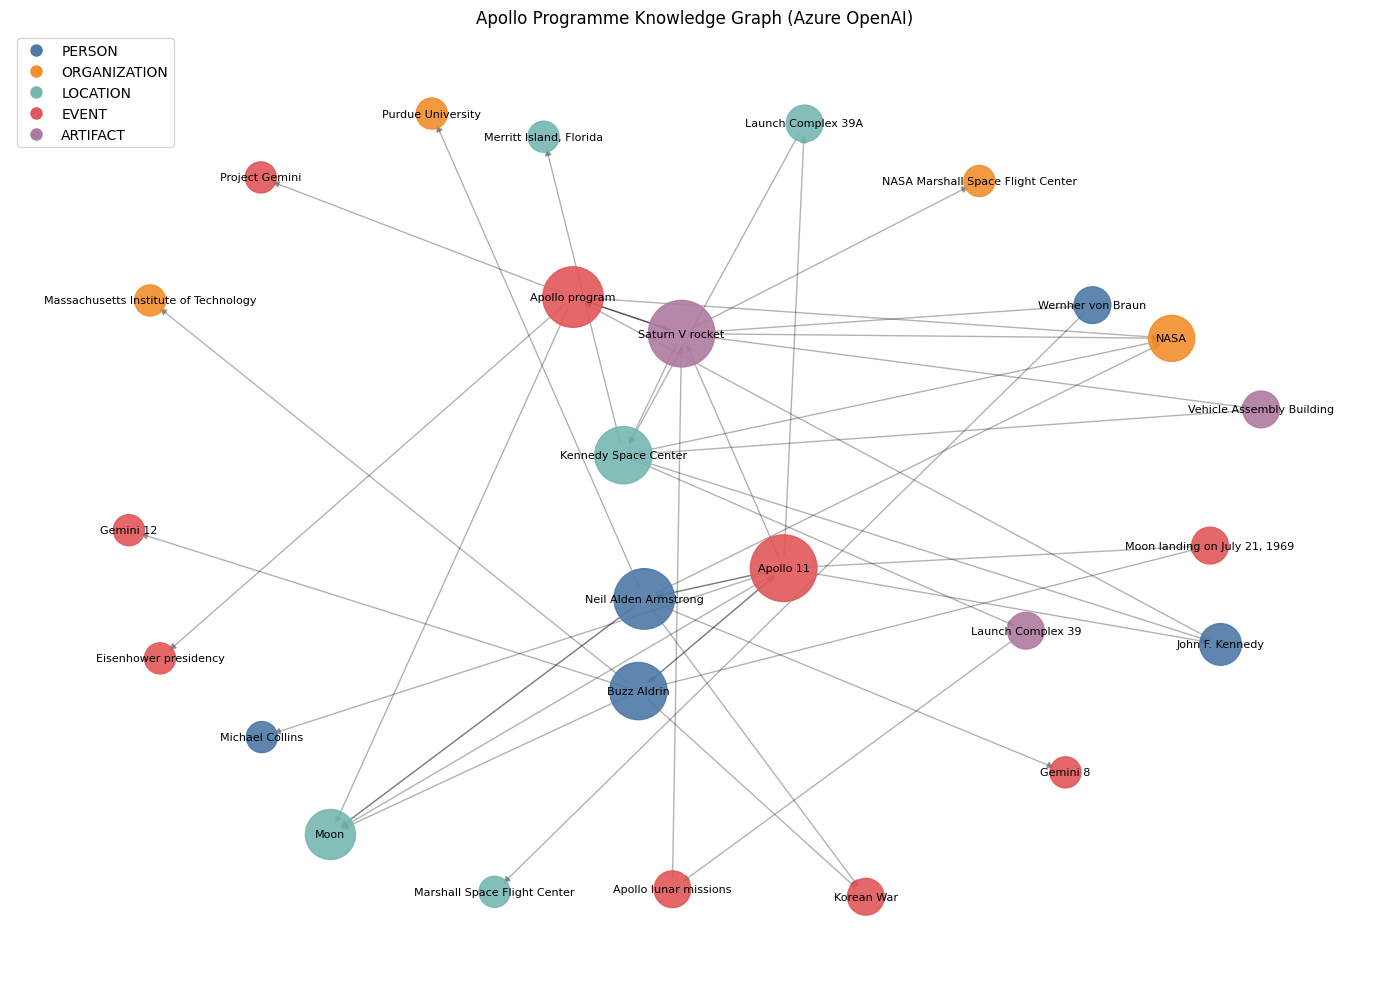

In [21]:
# ── Visualisation ─────────────────────────────────────────────────────────────
# Node colour = entity type. Node size = degree (hub nodes appear larger).
COLOR = {
    'PERSON':       '#4e79a7',
    'ORGANIZATION': '#f28e2c',
    'LOCATION':     '#76b7b2',
    'EVENT':        '#e15759',
    'ARTIFACT':     '#af7aa1',
}

plt.figure(figsize=(14, 10))
# spring_layout: force-directed — connected nodes pulled together, unconnected pushed apart
# seed=42 makes the layout reproducible
pos         = nx.spring_layout(G, k=1.5, seed=42)
node_colors = [COLOR[G.nodes[n]['type']] for n in G.nodes]
node_sizes  = [300 + 200 * G.degree(n) for n in G.nodes]   # hub nodes appear larger

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=t)
    for t, c in COLOR.items()
    if any(G.nodes[n]['type'] == t for n in G.nodes)   # only types actually in this graph
]
plt.legend(handles=handles, loc='upper left')
plt.title('Apollo Programme Knowledge Graph (Azure OpenAI)')
plt.axis('off')
plt.tight_layout()
plt.show()


## 6. Entity Summarisation

Generate rich profiles for the top-3 hub nodes.

**Why only hub nodes?**
One LLM call per node is expensive at scale. Hub nodes have the most cross-document
evidence — they benefit most from synthesis. A leaf node (one document, one mention)
has nothing to synthesise.

**What the profile adds beyond edges:**
Edges store individual facts. The profile synthesises them into prose, resolves
contradictions, and extracts key facts with a time range. Both representations
are useful — edges for graph traversal, profiles for reading.


In [22]:
SUMMARIZE_PROMPT = """Generate a knowledge-graph profile for this entity.

Entity: {name} ({etype})

Source excerpts mentioning this entity:
{excerpts}

Known relations in the graph:
{relations}

Write a 2-3 paragraph factual summary synthesised from the excerpts resolving any
contradictions by preferring the most specific claim. Include 3-5 atomic key facts
each traceable to the sources. For the time range use YYYY or YYYY-MM format or
unknown or ongoing where appropriate. Do not invent facts not supported by the excerpts."""


def summarize_entity(name: str) -> EntityProfile:
    """Summarise one graph node using its source documents and graph neighbourhood."""
    # 1. Pull full text of every document that mentions this node
    docs_with_entity = G.nodes[name]['source_docs']
    excerpts = '\n\n'.join(
        f"[{d['title']}]\n{d['text']}" for d in documents if d['title'] in docs_with_entity
    )

    # 2. Serialise the node neighbourhood as readable triples
    out_edges = '\n'.join(f"- {name} --{d['predicate']}--> {tgt}" for _, tgt, d in G.out_edges(name, data=True))
    in_edges  = '\n'.join(f"- {src} --{d['predicate']}--> {name}" for src, _, d in G.in_edges(name, data=True))
    relations = out_edges + '\n' + in_edges

    response = client.beta.chat.completions.parse(
        model=SYNTHESIS_DEPLOYMENT,
        max_tokens=1500,
        messages=[{'role': 'user', 'content': SUMMARIZE_PROMPT.format(
            name=name, etype=G.nodes[name]['type'],
            excerpts=excerpts, relations=relations,
        )}],
        response_format=EntityProfile,
    )
    return response.choices[0].message.parsed


In [23]:
# Summarise top-3 hub nodes and attach profiles to graph nodes
hub_nodes = [n for n, _ in sorted(G.degree(), key=lambda x: -x[1])[:3]]

for node in hub_nodes:
    profile = summarize_entity(node)
    G.nodes[node]['profile'] = profile.model_dump()   # attach to graph for serialisation

    print(f'=== {node} ===')
    print(profile.summary)
    print(f'\nTime range: {profile.time_range.start} - {profile.time_range.end}')
    print('Key facts:')
    for fact in profile.key_facts:
        print(f'  * {fact}')
    print()


=== Saturn V rocket ===
The Saturn V rocket was a super heavy-lift launch vehicle developed by NASA for the Apollo program under the direction of Wernher von Braun at the Marshall Space Flight Center. Standing 110.6 meters tall, it remains the most powerful rocket ever brought to operational status, capable of launching human missions beyond low Earth orbit. The Saturn V was integral to the success of the Apollo program, including the historic Apollo 11 mission which landed the first humans on the Moon in 1969.

From 1967 to 1973, a total of 13 Saturn V rockets were launched from Kennedy Space Center, specifically from Launch Complex 39A. The rockets were processed and assembled in the Vehicle Assembly Building, one of the world's largest structures by volume. Each Apollo lunar mission, including Apollo 11, utilized the Saturn V rocket, and all missions during this period were successfully launched without any payload loss, demonstrating the rocket's reliability and engineering excelle

## 7. Multi-hop Querying

**The core value over plain RAG.**

A RAG chunk might contain "Armstrong commanded Apollo 11" and separately
"Apollo 11 launched from KSC" — but if they never co-occur in one chunk, RAG misses the chain.
A graph traversal connects them explicitly.

**Grounded vs ungrounded:**
- Without context: model answers from pretraining - works for Apollo, **fails for private data**
- With context: model must cite specific edges - answers are traceable and auditable


In [24]:
def serialize_subgraph(center: str, hops: int = 2) -> str:
    """BFS N hops from center, return edges as triple strings.
    Example: (Neil Alden Armstrong) --[commanded]--> (Apollo 11)
    These triples are what gets injected as graph context into the LLM prompt.
    """
    nodes    = {center}
    frontier = {center}
    for _ in range(hops):
        nxt = set()
        for n in frontier:
            nxt |= set(G.successors(n)) | set(G.predecessors(n))   # undirected BFS
        frontier = nxt - nodes   # only newly discovered nodes
        nodes   |= frontier

    sub   = G.subgraph(nodes)
    lines = [f"({s}) --[{d['predicate']}]--> ({t})" for s, t, d in sub.edges(data=True)]
    return '\n'.join(sorted(set(lines)))   # sorted + deduplicated


def ask(question: str, graph_context: str = None) -> str:
    """Answer a question, optionally grounded in a serialised subgraph."""
    if graph_context is not None:
        prompt = (
            'Answer using only the knowledge graph below. '
            'Cite the specific edges that support your answer.\n\n'
            f'<graph>\n{graph_context}\n</graph>\n\nQuestion: {question}'
        )
    else:
        prompt = question

    # Plain completion — no structured output needed for free-form Q&A
    response = client.chat.completions.create(
        model=SYNTHESIS_DEPLOYMENT,
        max_tokens=500,
        messages=[{'role': 'user', 'content': prompt}],
    )
    return response.choices[0].message.content


In [25]:
center   = next((n for n in G.nodes if 'Apollo' in n), hub_nodes[0])
subgraph = serialize_subgraph(center, hops=2)
question = 'Which locations are connected to people who were part of Apollo 11, and how?'

print(f'Center node: {center}')
print(f'Subgraph: {len(subgraph.splitlines())} triples\n')

print('WITHOUT graph context (model uses pretraining):')
print(ask(question))

print('\n' + '-' * 60 + '\n')

print('WITH graph context (model must cite edges):')
print(ask(question, subgraph))
# Grounded answer cites specific edges. Ungrounded may be richer but is not
# traceable to your data — critical difference for private/proprietary domains.


Center node: Apollo program
Subgraph: 28 triples

WITHOUT graph context (model uses pretraining):
Certainly! **Apollo 11** was the NASA mission that first landed humans on the Moon in July 1969. The crew and other key individuals linked to Apollo 11 have locations (cities, towns, etc.) connected to them as places of birth, residence, or significant activities. Here’s a breakdown:

---

### 1. **Crew Members**

**NEIL ARMSTRONG** (Commander)  
- **Wapakoneta, Ohio**: Armstrong’s birthplace and childhood home.
- **West Lafayette, Indiana**: Purdue University, where he studied.
- **Houston, Texas**: Lived and worked at Johnson Space Center during his astronaut career.

**BUZZ ALDRIN** (Lunar Module Pilot)  
- **Glen Ridge, New Jersey**: Birthplace (sometimes associated with neighboring Montclair, where he grew up).
- **Montclair, New Jersey**: Childhood home.
- **Houston, Texas**: Lived/worked as an astronaut.

**MICHAEL COLLINS** (Command Module Pilot)  
- **Rome, Italy**: Birthplace (hi

## 8. Evaluation

Precision / Recall / F1 against a manually labelled gold set.

- **Precision:** of entities the LLM extracted, what fraction were correct?
- **Recall:** of entities that should have been extracted, what fraction did the LLM find?
- **F1:** harmonic mean, the single number to tune the extraction prompt against.
- **Resolution recall:** did the resolver map surface forms to the right canonical?
  This is measured separately - you can extract correctly but resolve wrongly.


In [26]:
# Manually verified correct entities per document
GOLD = {
    'Apollo 11': {'entities': [
        {'name': 'Neil Armstrong'}, {'name': 'Buzz Aldrin'}, {'name': 'Michael Collins'},
        {'name': 'Apollo program'}, {'name': 'Moon'}, {'name': 'Saturn V'}, {'name': 'NASA'},
        {'name': 'Kennedy Space Center'}, {'name': 'Apollo 11'},
    ]},
    'Neil Armstrong': {'entities': [
        {'name': 'Neil Armstrong'}, {'name': 'NASA'}, {'name': 'Apollo 11'},
        {'name': 'Gemini 8'}, {'name': 'Moon'}, {'name': 'Korean War'}, {'name': 'Purdue University'},
    ]},
}

# Known aliases for eval normalisation — so 'Neil Alden Armstrong' matches gold 'Neil Armstrong'
ALIASES_EVAL = {
    'neil alden armstrong': 'neil armstrong',
    'edwin aldrin':         'buzz aldrin',
    'the moon':             'moon',
    'ksc':                  'kennedy space center',
}


def norm(name: str) -> str:
    return ALIASES_EVAL.get(name.lower().strip(), name.lower().strip())


def prf(predicted: set, gold: set):
    tp = len(predicted & gold)
    p  = tp / len(predicted) if predicted else 0.0
    r  = tp / len(gold)      if gold      else 0.0
    f1 = 2 * p * r / (p + r) if (p + r)  else 0.0
    return p, r, f1


print('Extraction + resolution quality vs gold standard:\n')
for doc_title, labels in GOLD.items():
    gold_names = {norm(e['name']) for e in labels['entities']}

    raw        = {norm(e['name']) for e in raw_entities if e['source_doc'] == doc_title}
    rp, rr, rf = prf(raw, gold_names)

    resolved   = {norm(alias_to_canonical.get(e['name'], e['name']))
                  for e in raw_entities if e['source_doc'] == doc_title}
    _, res_r, _ = prf(resolved, gold_names)

    print(f'{doc_title:<20}  raw F1={rf:.2f} (P={rp:.2f} R={rr:.2f})  resolved R={res_r:.2f}')
    missed = gold_names - resolved
    if missed:
        print(f"  missed after resolution: {', '.join(sorted(missed))}")
    # resolved R > raw R  -> resolution recovered entities via alias merging
    # resolved R < raw R  -> resolution over-merged and lost entities


Extraction + resolution quality vs gold standard:

Apollo 11             raw F1=0.67 (P=0.67 R=0.67)  resolved R=0.67
  missed after resolution: apollo program, nasa, saturn v
Neil Armstrong        raw F1=1.00 (P=1.00 R=1.00)  resolved R=1.00
